In [67]:
from stress_risk.utils.data import Subject, get_all_behavior, get_group_mapping
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
df = get_all_behavior()

mapping = get_group_mapping()

/Users/gdehol/git/stress_risk/stress_risk/utils/data.py:213: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '20%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '32%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '44%', '56%', '56%', '56%', '56%', '56%', '56%', '56%', '56%

In [69]:
pars_new_smoothed = pd.read_csv('/data/ds-stressrisk/derivatives/summary_encoding_models.smoothed/group_roi-NPC_R_parameters.tsv', sep='\t', header=[0, 1], index_col=[0, 1, 2])
pars_new_smoothed.index.set_names(['subject', 'model_label', 'voxel'], inplace=True)
pars_old_smoothed = pd.read_csv('/data/ds-stressrisk/derivatives/summary_encoding_models.old.smoothed/group_roi-NPC_R_parameters.tsv', sep='\t', header=[0, 1], index_col=[0, 1])
pars_old_smoothed['model_label'] = -1
pars_old_smoothed.set_index('model_label', append=True, inplace=True)
pars_old_smoothed.index.set_names(['subject', 'voxel', 'model_label'], inplace=True)
pars_old_smoothed = pars_old_smoothed.reorder_levels(['subject', 'model_label', 'voxel'], axis=0)

pars = pd.concat([pars_new_smoothed, pars_old_smoothed], keys=[('new', 'smoothed'), ('old', 'smoothed')], names=['type', 'smoothed'], axis=0)

mapping = get_group_mapping()

pars['group'] = pars.index.get_level_values('subject').map(mapping)

pars.set_index('group', append=True, inplace=True)

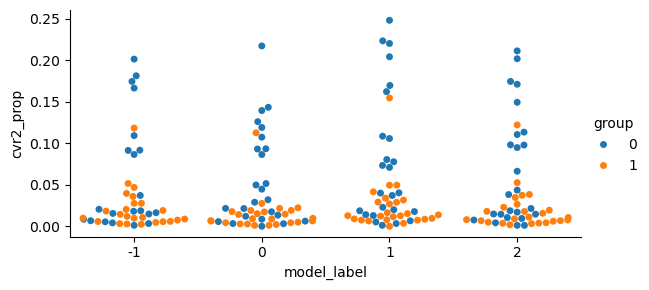

In [94]:
cvr2_mask = pars[('cvr2', 'nan')] > 0.0


cvr2_prop = cvr2_mask.groupby(['group', 'subject', 'model_label']).mean()


sns.catplot(data=cvr2_prop.to_frame('cvr2_prop').reset_index(), x='model_label', y='cvr2_prop', kind='swarm', hue='group', aspect=2, height=3.)

Text(0.5, 1.0, 'Proportion of voxels with cvR2>0')

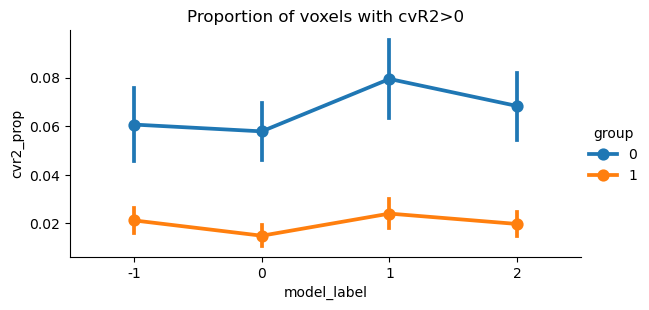

In [95]:
cvr2_mask = pars[('cvr2', 'nan')] > 0.0


cvr2_prop = cvr2_mask.groupby(['group', 'subject', 'model_label']).mean()


sns.catplot(data=cvr2_prop.to_frame('cvr2_prop').reset_index(), x='model_label', y='cvr2_prop', kind='point', errorbar='se', height=3, aspect=2, hue='group')
plt.title('Proportion of voxels with cvR2>0')

In [96]:
pd.concat((pars.xs(-1, level='model_label', drop_level=False), pars.xs(2, level='model_label', drop_level=False)))[cvr2_mask]['mu'].reset_index('type', drop=True).unstack('model_label').corr()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19622/1045463620.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pd.concat((pars.xs(-1, level='model_label', drop_level=False), pars.xs(2, level='model_label', drop_level=False)))[cvr2_mask]['mu'].reset_index('type', drop=True).unstack('model_label').corr()


session                   1.0                 2.0          
model_label                -1         2        -1         2
session model_label                                        
1.0     -1           1.000000  0.842406  0.226164  0.164024
         2           0.842406  1.000000  0.117464  0.134496
2.0     -1           0.226164  0.117464  1.000000  0.883840
         2           0.164024  0.134496  0.883840  1.000000

Text(0.5, 1.0, 'Proportion of voxels where model wins (only for voxels with cvR2>0)')

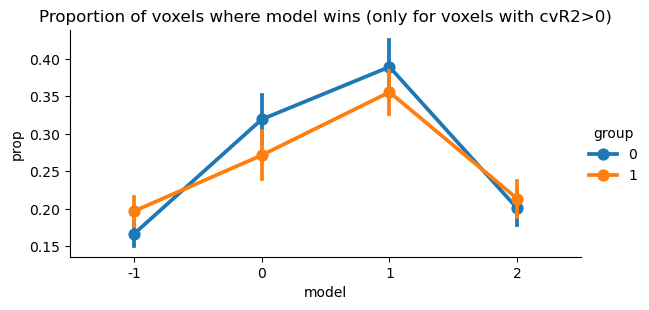

In [102]:

winning_models = pars[cvr2_mask][('cvr2', 'nan')].reset_index('type', drop=True).unstack('model_label').idxmax(axis=1)
mean_winning_model = winning_models.groupby(['subject', 'group']).value_counts(normalize=True)

mean_winning_model.index.set_names('model', level=-1, inplace=True)

sns.catplot(data=mean_winning_model.to_frame('prop').reset_index(), x='model', y='prop', hue='group', kind='point', errorbar='se', height=3. ,aspect=2.)
plt.title("Proportion of voxels where model wins (only for voxels with cvR2>0)")

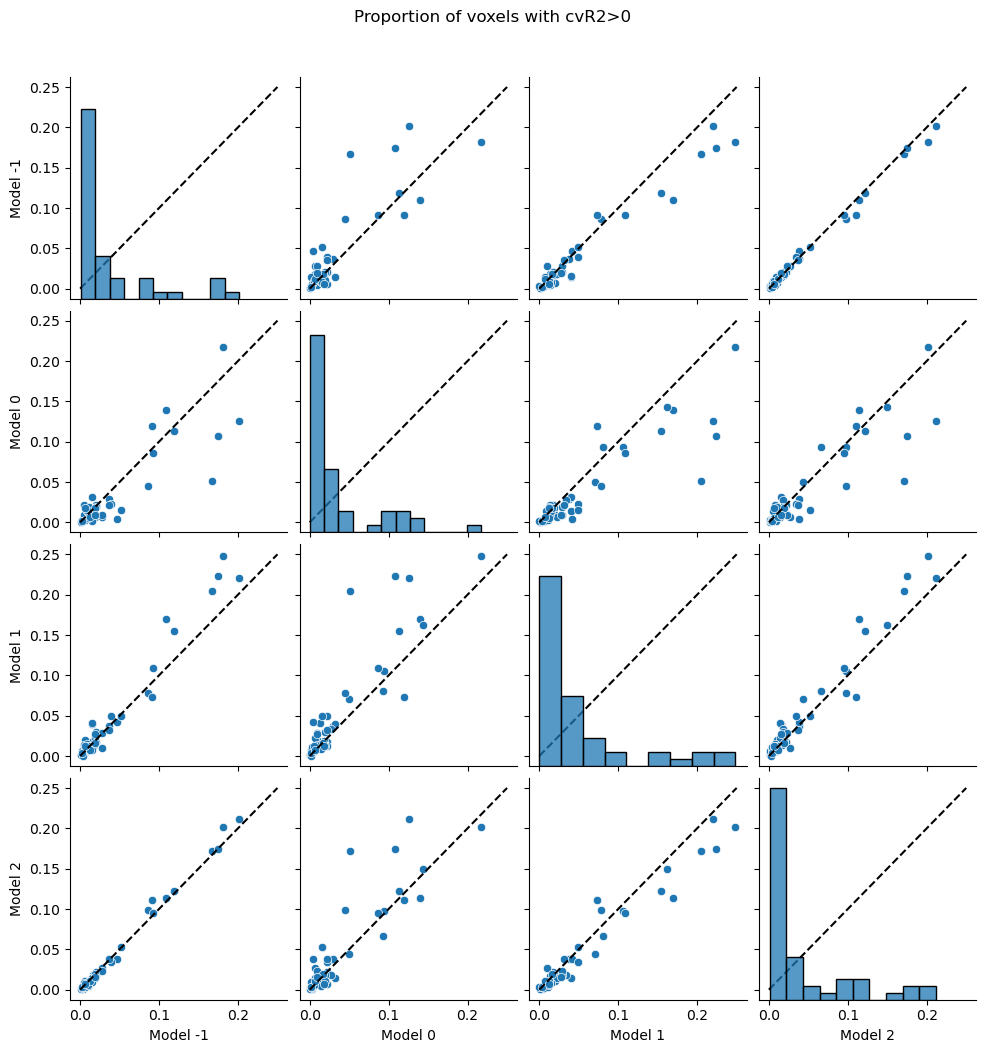

In [111]:
tmp = cvr2_prop.unstack()

tmp.columns = [f'Model {name}' for name in tmp.columns]
g = sns.pairplot(tmp)

g.fig.suptitle('Proportion of voxels with cvR2>0', y=1.05)

g.set()
g.map(lambda *args, **kwargs: plt.plot([0, .25], [0, .25], 'k--'))


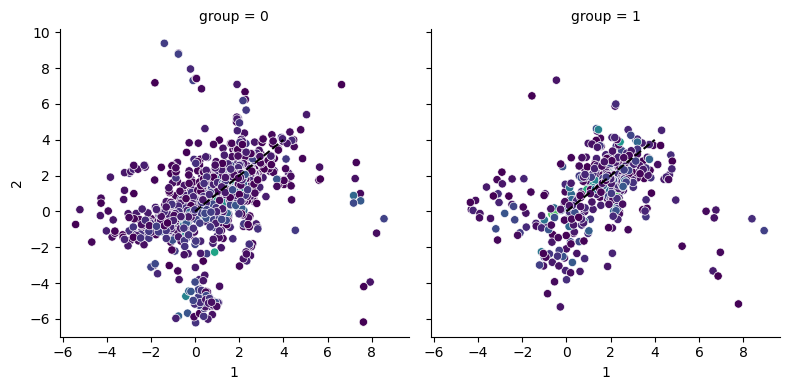

In [55]:
tmp = pars[cvr2_mask]['mu'].xs(1, level='model_label')

cvr2 = pars[('cvr2', 'nan')].xs(1, level='model_label')


tmp.columns = [1,2]

tmp['cvr2'] = cvr2

g = sns.FacetGrid(tmp.reset_index(), col='group', height=4.)
g.map_dataframe(sns.scatterplot, x=1, y=2, hue='cvr2', palette='viridis')
# sns.scatterplot(data=tmp, x=1, y=2, hue='cvr2', palette='viridis')

# plot identity line
g.map(lambda *args, **kwargs: plt.plot([0, 4], [0, 4], color='k', linestyle='--'))


# plt.figure()
# sns.histplot(data=tmp, x=1, y=2, palette='viridis', bins=(100, 100))




/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 78.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 74.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 78.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


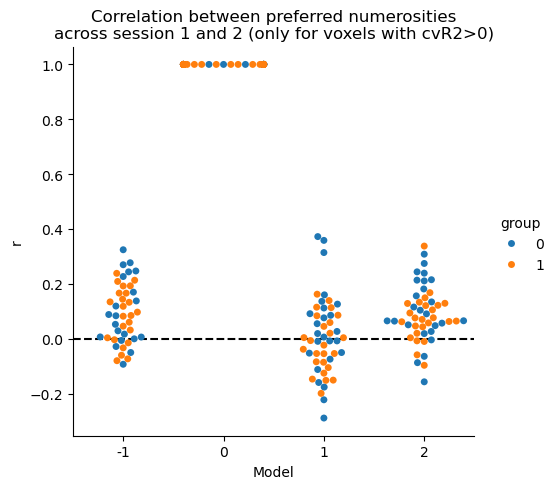

In [116]:
import pingouin as pg
tmp = pars[~cvr2_mask]['mu'].groupby(['model_label', 'group', 'subject']).apply(lambda x: pg.corr(x['1.0'], x['2.0'], method='pearson') if len(x) > 10 else None)


g = sns.catplot(data=tmp.reset_index(), x='model_label', y='r', kind='swarm', hue='group')

plt.title('Correlation between preferred numerosities\nacross session 1 and 2 (only for voxels with cvR2>0)')

g.set(xlabel='Model')

g.map(lambda *args, **kwargs: plt.axhline(0, color='k', linestyle='--'))

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 63.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 56.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 63.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


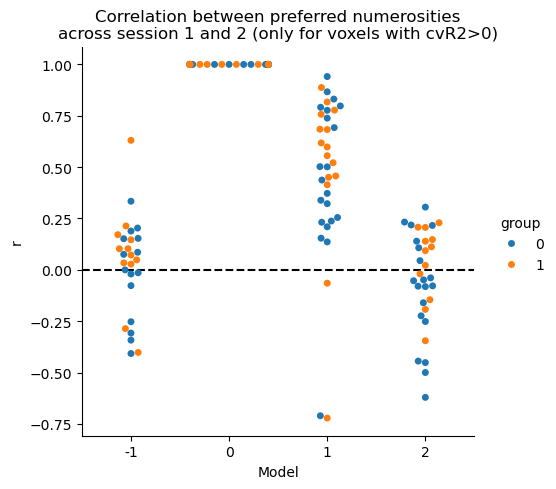

In [115]:
import pingouin as pg
tmp = pars[cvr2_mask]['mu'].groupby(['model_label', 'group', 'subject']).apply(lambda x: pg.corr(x['1.0'], x['2.0'], method='pearson') if len(x) > 10 else None)


g = sns.catplot(data=tmp.reset_index(), x='model_label', y='r', kind='swarm', hue='group')

plt.title('Correlation between preferred numerosities\nacross session 1 and 2 (only for voxels with cvR2>0)')

g.set(xlabel='Model')

g.map(lambda *args, **kwargs: plt.axhline(0, color='k', linestyle='--'))

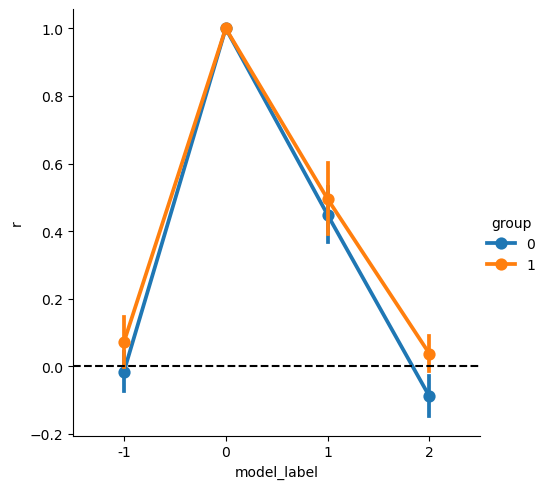

In [59]:
import pingouin as pg
tmp = pars[cvr2_mask]['mu'].groupby(['model_label', 'group', 'subject']).apply(lambda x: pg.corr(x['1.0'], x['2.0'], method='pearson') if len(x) > 10 else None)


sns.catplot(data=tmp.reset_index(), x='model_label', y='r', kind='point', hue='group', errorbar='se')
plt.axhline(0.0, color='k', linestyle='--')

In [77]:
import numpy as np

min_range = df.groupby(['subject'])['n1'].min()
max_range = df.groupby(['subject'])['n1'].max()


# Check for every parameter settings whether mu_natural is within the correspondign range...
pars['min_range'] = pars.index.get_level_values('subject').map(min_range)
pars['max_range'] = pars.index.get_level_values('subject').map(max_range)
# pars['monotonic'] = (pars['mu'] >= pars['min_range']).all(axis=1) #& (pars['mu'] <= pars['max_range'].all(axis=1))

pars['monotonic'] = (pars['mu_natural'] > pars['min_range'].values[:, np.newaxis]).all(axis=1) & (pars['mu_natural'] < pars['max_range'].values[:, np.newaxis]).all(axis=1)


monotonic_mask = pars['monotonic']

In [127]:
pars[pars['r2'] > 0.1]

parameter                                      mu      sd     amplitude      \
session                                       1.0 2.0 1.0 2.0       1.0 2.0   
type smoothed subject model_label voxel group                                 
new  smoothed 1        0          0     0     NaN NaN NaN NaN       NaN NaN   
                                  1     0     NaN NaN NaN NaN       NaN NaN   
                                  2     0     NaN NaN NaN NaN       NaN NaN   
                                  3     0     NaN NaN NaN NaN       NaN NaN   
                                  4     0     NaN NaN NaN NaN       NaN NaN   
...                                            ..  ..  ..  ..       ...  ..   
old  smoothed 61      -1          1037  0     NaN NaN NaN NaN       NaN NaN   
                                  1038  0     NaN NaN NaN NaN       NaN NaN   
                                  1039  0     NaN NaN NaN NaN       NaN NaN   
                                  1040  0     NaN NaN NaN NaN       NaN NaN   
                                  1041  0     NaN NaN NaN NaN       NaN NaN   

parameter                                     baseline     cvr2  r2  \
session                                            1.0 2.0  nan nan   
type smoothed subject model_label voxel group                         
new  smoothed 1        0          0     0          NaN NaN  NaN NaN   
                                  1     0          NaN NaN  NaN NaN   
                                  2     0          NaN NaN  NaN NaN   
                                  3     0          NaN NaN  NaN NaN   
                                  4     0          NaN NaN  NaN NaN   
...                                                ...  ..  ...  ..   
old  smoothed 61      -1          1037  0          NaN NaN  NaN NaN   
                                  1038  0          NaN NaN  NaN NaN   
                                  1039  0          NaN NaN  NaN NaN   
                                  1040  0          NaN NaN  NaN NaN   
                                  1041  0          NaN NaN  NaN NaN   

parameter                                     mu_natural     cvr2      r2      
session                                              1.0 2.0  1.0 2.0 1.0 2.0  
type smoothed subject model_label voxel group                                  
new  smoothed 1        0          0     0            NaN NaN  NaN NaN NaN NaN  
                                  1     0            NaN NaN  NaN NaN NaN NaN  
                                  2     0            NaN NaN  NaN NaN NaN NaN  
                                  3     0            NaN NaN  NaN NaN NaN NaN  
                                  4     0            NaN NaN  NaN NaN NaN NaN  
...                                                  ...  ..  ...  ..  ..  ..  
old  smoothed 61      -1          1037  0            NaN NaN  NaN NaN NaN NaN  
                                  1038  0            NaN NaN  NaN NaN NaN NaN  
                                  1039  0            NaN NaN  NaN NaN NaN NaN  
                                  1040  0            NaN NaN  NaN NaN NaN NaN  
                                  1041  0            NaN NaN  NaN NaN NaN NaN  

[182993 rows x 16 columns]

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


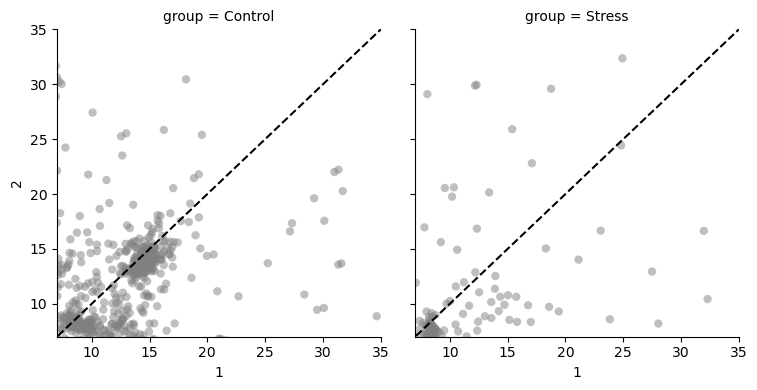

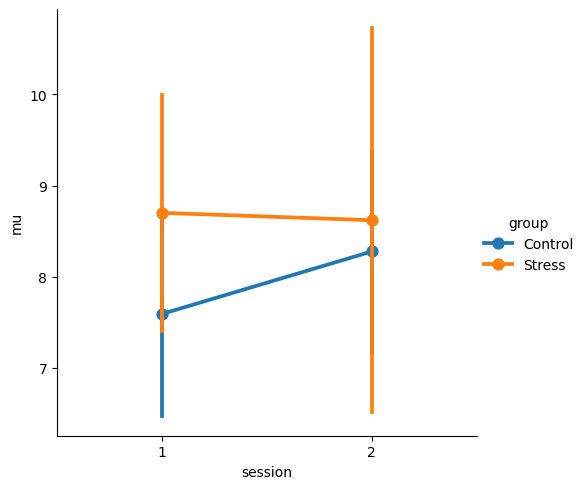

In [138]:
tmp = pars[cvr2_mask]['mu_natural'].xs(1, level='model_label')
cvr2 = pars[('cvr2', 'nan')].xs(1, level='model_label')
tmp.columns = [1,2]

order = tmp.index.names
tmp = tmp.reset_index('group', drop=False)
tmp['group'] = tmp['group'].map({0:'Control', 1:'Stress'})
tmp = tmp.set_index('group', append=True)
tmp.reorder_levels(order, axis=0)

tmp['cvr2'] = cvr2

g = sns.FacetGrid(tmp.reset_index(), col='group', height=4.)
g.map_dataframe(sns.scatterplot, x=1, y=2, palette='viridis', color='gray', edgecolor='none', alpha=.5)
# sns.scatterplot(data=tmp, x=1, y=2, hue='cvr2', palette='viridis')

# plot identity line
g.map(lambda *args, **kwargs: plt.plot([5, 50], [5, 50], color='k', linestyle='--'))



plt.xlim(7, 35)
plt.ylim(7, 35)

mu_session = tmp[[1, 2]].stack().to_frame("mu")

mu_session.index.set_names(level=-1, names='session', inplace=True)

sns.catplot(x='session', y='mu', data=mu_session.groupby(['subject', 'group', 'session']).median().reset_index(), kind='point', hue='group', errorbar='se')

In [124]:
tmp

1          2      cvr2
type smoothed subject voxel group                                
new  smoothed 1       84    0      14.810926  47.993717  0.015900
                      163   0      73.201940  84.363500  0.008662
                      241   0      14.733981  10.937902  0.001363
                      252   0       3.362337  14.072003  0.027934
                      272   0      30.073906   9.625378  0.023655
...                                      ...        ...       ...
              61      881   0       1.426243   1.912558  0.015273
                      882   0       0.527845   0.752460  0.020260
                      883   0       0.270467   1.280595  0.012617
                      884   0       2.484195  13.308101  0.009347
                      910   0       0.287687   0.526727  0.000165

[2470 rows x 3 columns]

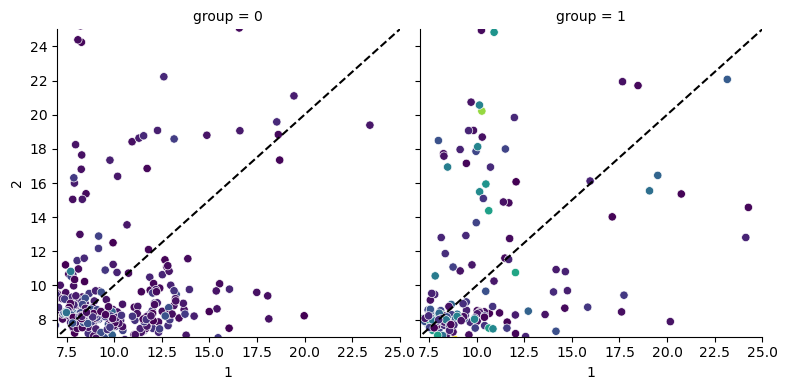

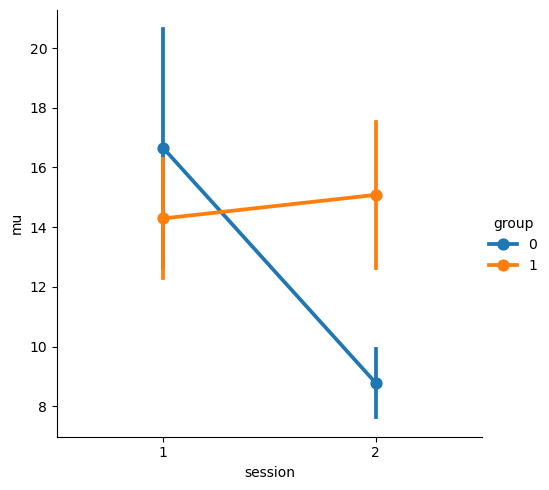

In [122]:
tmp = pars[cvr2_mask]['mu_natural'].xs(-1, level='model_label')
cvr2 = pars[('cvr2', 'nan')].xs(-1, level='model_label')
tmp.columns = [1,2]

tmp['cvr2'] = cvr2

g = sns.FacetGrid(tmp.reset_index(), col='group', height=4.)
g.map_dataframe(sns.scatterplot, x=1, y=2, hue='cvr2', palette='viridis')
# sns.scatterplot(data=tmp, x=1, y=2, hue='cvr2', palette='viridis')

# plot identity line
g.map(lambda *args, **kwargs: plt.plot([5, 50], [5, 50], color='k', linestyle='--'))

plt.xlim(7, 25)
plt.ylim(7, 25)

mu_session = tmp[[1, 2]].stack().to_frame("mu")

mu_session.index.set_names(level=-1, names='session', inplace=True)

sns.catplot(x='session', y='mu', data=mu_session.groupby(['subject', 'group', 'session']).median().reset_index(), kind='point', hue='group', errorbar='se')

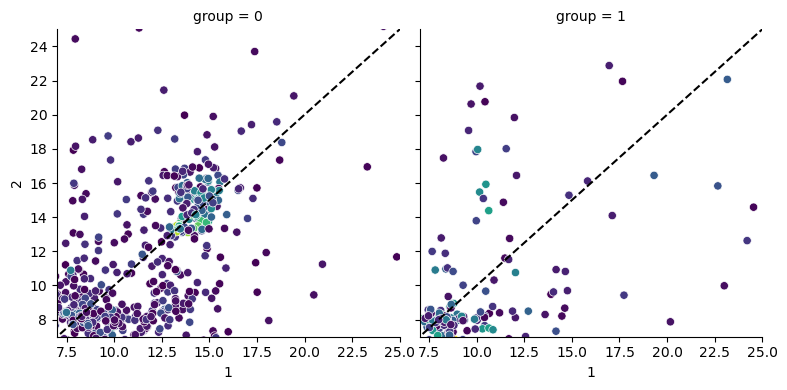

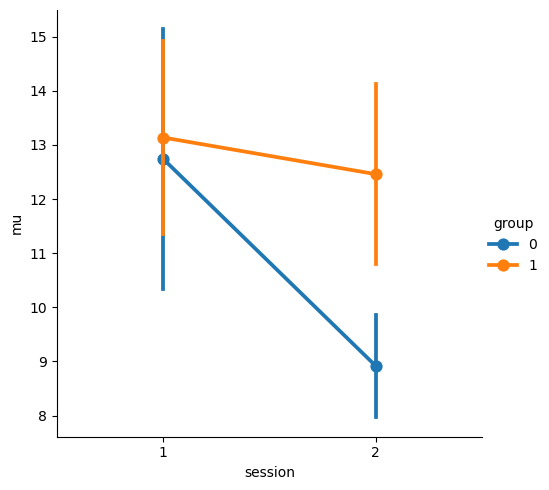

In [88]:
tmp = pars[cvr2_mask]['mu_natural'].xs(2, level='model_label')
cvr2 = pars[('cvr2', 'nan')].xs(2, level='model_label')
tmp.columns = [1,2]

tmp['cvr2'] = cvr2

g = sns.FacetGrid(tmp.reset_index(), col='group', height=4.)
g.map_dataframe(sns.scatterplot, x=1, y=2, hue='cvr2', palette='viridis')
# sns.scatterplot(data=tmp, x=1, y=2, hue='cvr2', palette='viridis')

# plot identity line
g.map(lambda *args, **kwargs: plt.plot([5, 50], [5, 50], color='k', linestyle='--'))

plt.xlim(7, 25)
plt.ylim(7, 25)

mu_session = tmp[[1, 2]].stack().to_frame("mu")

mu_session.index.set_names(level=-1, names='session', inplace=True)

sns.catplot(x='session', y='mu', data=mu_session.groupby(['subject', 'group', 'session']).median().reset_index(), kind='point', hue='group', errorbar='se')

In [66]:
pg.mixed_anova(data=mu_session.reset_index(), dv='mu', within='session', between='group', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,1590.111994,1,47,1590.111994,0.833961,0.365790,0.017435,NaN
1,session,1733.781087,1,47,1733.781087,1.118380,0.295673,0.023242,1.0
2,Interaction,4633.234296,1,47,4633.234296,2.988679,0.090413,0.059787,NaN


In [ ]:
tmp = pars['mu'].droplevel('type', axis=0).unstack('model_label').swaplevel(axis=1)[[-1, 2]]



model_label                         -1                   2          
session                            1.0       2.0       1.0       2.0
smoothed subject voxel group                                        
smoothed 1       0     0      4.245952  2.119433  1.328036  2.119463
                 1     0      4.524127  2.378419  2.068838  2.378396
                 2     0      4.258342  2.152342  1.314544  2.153430
                 3     0      4.141740  2.600156  4.141691  2.598250
                 4     0      4.262557  2.136701  4.054737  2.136701
...                                ...       ...       ...       ...
         61      1037  0      2.984016  3.605516  2.984016  3.605514
                 1038  0      3.075528  2.636811  3.075513  1.856007
                 1039  0      3.126882  3.406817  3.318480  3.406805
                 1040  0      3.467937  3.496656  3.450995  3.496640
                 1041  0      2.924822  1.854337  2.924728  1.657943

[46875 rows x 4 columns]